# UVA Analysis: Foreign Giving to the University of Virginia

This notebook analyzes foreign giving to the **University of Virginia (UVA)** specifically, comparing it to:
1. A set of **peer public flagship universities**
2. The **overall market** of US academic institutions

We then propose a data-driven strategy for UVA to grow foreign philanthropic support.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv('ForeignGifts_edu.csv', low_memory=False)
df['Gift Date'] = pd.to_datetime(df['Foreign Gift Received Date'], unit='D', origin='1899-12-30')
df['Gift Year'] = df['Gift Date'].dt.year

UVA = 'University of Virginia'
print(df.shape)
df[df['Institution Name'] == UVA].head()

(28221, 12)


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name,Gift Date,Gift Year
26235,26236,374500,University of Virginia,Charlottesville,VA,41822,3565,Monetary Gift,ENGLAND,West Yorkshire Police,2014-07-02,2014
26236,26237,374500,University of Virginia,Charlottesville,VA,41870,12265,Contract,ISRAEL,CureTech Ltd,2014-08-19,2014
26237,26238,374500,University of Virginia,Charlottesville,VA,41873,8187,Monetary Gift,ISRAEL,Branco Weiss Institute,2014-08-22,2014
26238,26239,374500,University of Virginia,Charlottesville,VA,41887,6437,Contract,ISRAEL,NovoCure Ltd,2014-09-05,2014
26239,26240,374500,University of Virginia,Charlottesville,VA,41904,216943,Contract,ISRAEL,InSightec-Image Guide Treatment Ltd,2014-09-22,2014


## Defining a Peer Group

UVA is typically benchmarked against other flagship public AAU universities. We define a peer set below, matching institution names exactly as they appear in the dataset.

In [2]:
PEERS = [
    'University of Virginia',
    'College of William & Mary',
    'University of North Carolina - Chapel Hill',
    'North Carolina State University',
    'University of Michigan - Ann Arbor',
    'University of Wisconsin - Madison',
    'University of California, Berkeley',
    'University of California, Los Angeles',
    'Georgia Institute of Technology',
    'Ohio State University (The)',
    'University of Texas at Austin',
]

peer_df = df[df['Institution Name'].isin(PEERS)].copy()
market_df = df.copy()

print(f"Peer group gifts: {len(peer_df):,} rows across {peer_df['Institution Name'].nunique()} institutions")
print(f"Full market gifts: {len(market_df):,} rows across {market_df['Institution Name'].nunique()} institutions")

Peer group gifts: 7,072 rows across 11 institutions
Full market gifts: 28,221 rows across 318 institutions


## UVA vs. Peers: Total Amount and Gift Count

How does UVA rank among its peers, in both total dollars received and number of gifts?

In [3]:
peer_summary = (
    peer_df.groupby('Institution Name')['Foreign Gift Amount']
    .agg(total_amount='sum', gift_count='count', avg_amount='mean', median_amount='median')
    .sort_values('total_amount', ascending=False)
)
peer_summary['rank_by_total'] = range(1, len(peer_summary) + 1)
peer_summary



,total_amount,gift_count,avg_amount,median_amount,rank_by_total
Institution Name,,,,,
"University of California, Berkeley",294479904,394,"747,410.92","424,025.00",1
University of Michigan - Ann Arbor,287336783,715,"401,869.63","200,000.00",2
"University of California, Los Angeles",242146363,3916,"61,835.13",250.00,3
University of Texas at Austin,85858408,377,"227,741.14","97,911.00",4
Georgia Institute of Technology,77979361,203,"384,134.78","167,435.00",5
Ohio State University (The),58277670,1014,"57,473.05","8,040.00",6
University of North Carolina - Chapel Hill,41292544,286,"144,379.52","33,548.00",7
North Carolina State University,23762788,14,"1,697,342.00","348,732.00",8
University of Wisconsin - Madison,22945761,38,"603,835.82","379,256.50",9


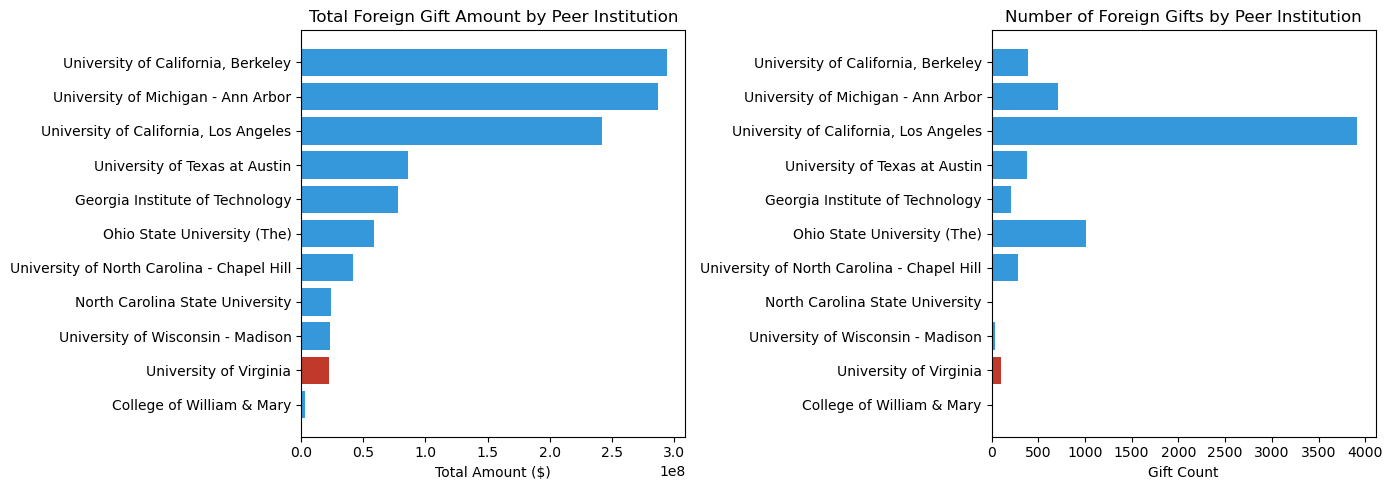

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#c0392b' if inst == UVA else '#3498db' for inst in peer_summary.index]

axes[0].barh(peer_summary.index, peer_summary['total_amount'], color=colors)
axes[0].invert_yaxis()
axes[0].set_title('Total Foreign Gift Amount by Peer Institution')
axes[0].set_xlabel('Total Amount ($)')

axes[1].barh(peer_summary.index, peer_summary['gift_count'], color=colors)
axes[1].invert_yaxis()
axes[1].set_title('Number of Foreign Gifts by Peer Institution')
axes[1].set_xlabel('Gift Count')

plt.tight_layout()
plt.show()

## UVA vs. the Overall Market

Where does UVA rank among *all* US institutions receiving foreign gifts (not just peers)?

In [5]:
market_totals = market_df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)
market_counts = market_df.groupby('Institution Name')['Foreign Gift Amount'].count().sort_values(ascending=False)

uva_total = market_totals.loc[UVA]
uva_count = market_counts.loc[UVA]

total_rank = market_totals.rank(ascending=False).loc[UVA]
count_rank = market_counts.rank(ascending=False).loc[UVA]
n_institutions = market_totals.shape[0]

total_pctile = 100 * (1 - total_rank / n_institutions)
count_pctile = 100 * (1 - count_rank / n_institutions)

print(f"UVA total foreign gifts received: ${uva_total:,.0f}")
print(f"UVA rank by total amount: {int(total_rank)} of {n_institutions} ({total_pctile:.1f}th percentile)")
print()
print(f"UVA number of foreign gifts: {uva_count:,}")
print(f"UVA rank by gift count: {int(count_rank)} of {n_institutions} ({count_pctile:.1f}th percentile)")

UVA total foreign gifts received: $22,189,238
UVA rank by total amount: 101 of 318 (68.2th percentile)

UVA number of foreign gifts: 98
UVA rank by gift count: 57 of 318 (82.1th percentile)


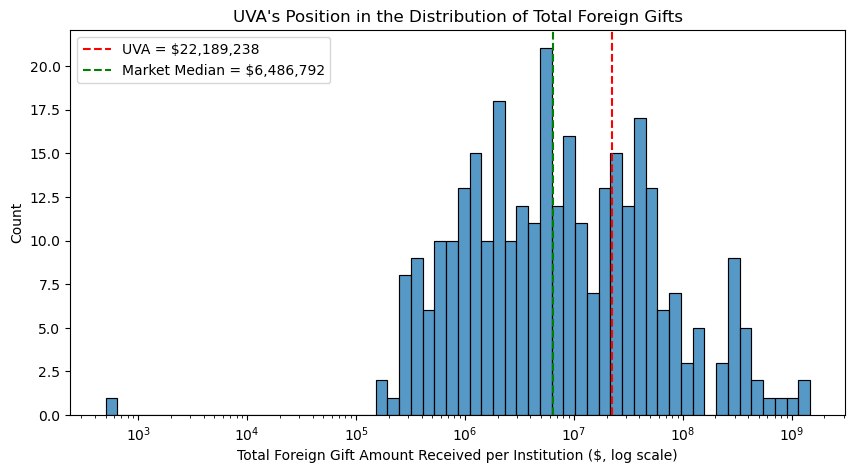

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(market_totals, bins=60, log_scale=(True, False))
plt.axvline(uva_total, color='red', linestyle='--', label=f'UVA = ${uva_total:,.0f}')
plt.axvline(market_totals.median(), color='green', linestyle='--', label=f'Market Median = ${market_totals.median():,.0f}')
plt.xlabel('Total Foreign Gift Amount Received per Institution ($, log scale)')
plt.title("UVA's Position in the Distribution of Total Foreign Gifts")
plt.legend()
plt.show()

## UVA's Donor Countries

Which countries currently give to UVA, and how concentrated is that giving?

UVA has received gifts from 15 distinct countries

                   total_amount  gift_count
Country of Giftor                          
BANGLADESH              4228589          10
SWEDEN                  4007552          10
TANZANIA                2776447           3
SWITZERLAND             2000000           2
ENGLAND                 1950666          31
GUERNSEY                1500000           3
FINLAND                 1008384           7
BERMUDA                  900000           1
KOREA                    862787           6
SINGAPORE                805000           2
THE NETHERLANDS          725670           4
ISRAEL                   623655          12
RWANDA                   284135           1
JAPAN                    265970           1
FRANCE                   250383           5


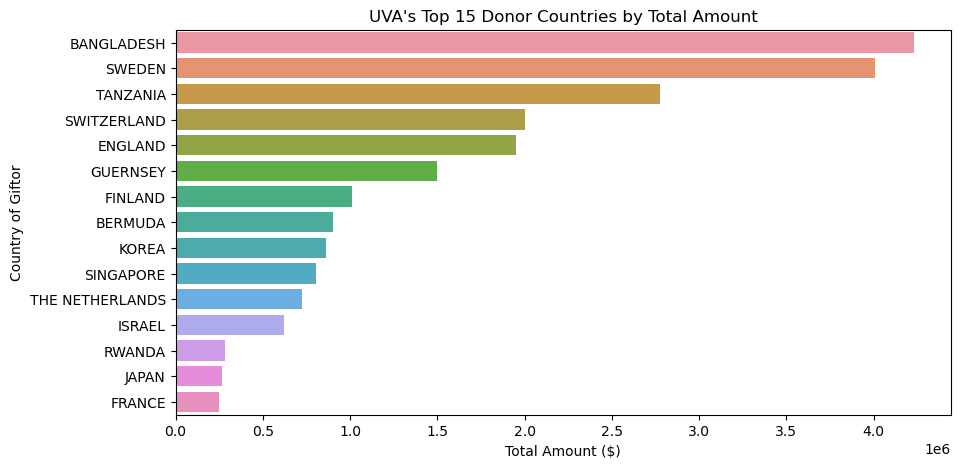

In [7]:
uva_df = df[df['Institution Name'] == UVA].copy()

uva_by_country = (
    uva_df.groupby('Country of Giftor')['Foreign Gift Amount']
    .agg(total_amount='sum', gift_count='count')
    .sort_values('total_amount', ascending=False)
)

print(f"UVA has received gifts from {uva_by_country.shape[0]} distinct countries")
print()
print(uva_by_country.head(15))

plt.figure(figsize=(10, 5))
sns.barplot(x=uva_by_country['total_amount'].head(15), y=uva_by_country.head(15).index)
plt.title("UVA's Top 15 Donor Countries by Total Amount")
plt.xlabel('Total Amount ($)')
plt.show()

### Concentration of UVA's Giving vs. Peers

We measure concentration with the share of total dollars coming from UVA's single largest donor country, and compare the number of distinct donor countries against peers (normalized by total dollars raised, since bigger fundraising operations naturally have more countries).

In [8]:
def concentration_stats(sub_df):
    by_country = sub_df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False)
    total = by_country.sum()
    top1_share = by_country.iloc[0] / total if total > 0 else np.nan
    n_countries = by_country.shape[0]
    return pd.Series({
        'n_countries': n_countries,
        'top1_share': top1_share,
        'total_amount': total
    })

peer_concentration = (
    peer_df.groupby('Institution Name')
    .apply(concentration_stats)
    .sort_values('total_amount', ascending=False)
)
peer_concentration

,n_countries,top1_share,total_amount
Institution Name,,,
"University of California, Berkeley",37.00,0.12,"294,479,904.00"
University of Michigan - Ann Arbor,42.00,0.16,"287,336,783.00"
"University of California, Los Angeles",37.00,0.22,"242,146,363.00"
University of Texas at Austin,25.00,0.18,"85,858,408.00"
Georgia Institute of Technology,22.00,0.27,"77,979,361.00"
Ohio State University (The),21.00,0.23,"58,277,670.00"
University of North Carolina - Chapel Hill,20.00,0.34,"41,292,544.00"
North Carolina State University,10.00,0.81,"23,762,788.00"
University of Wisconsin - Madison,16.00,0.33,"22,945,761.00"


## Gift Type Mix: UVA vs. Peers

Does UVA rely more on Monetary Gifts, or on Contracts (e.g. sponsored research)? This has implications for whether growth should focus on major-gift fundraising vs. research partnerships.

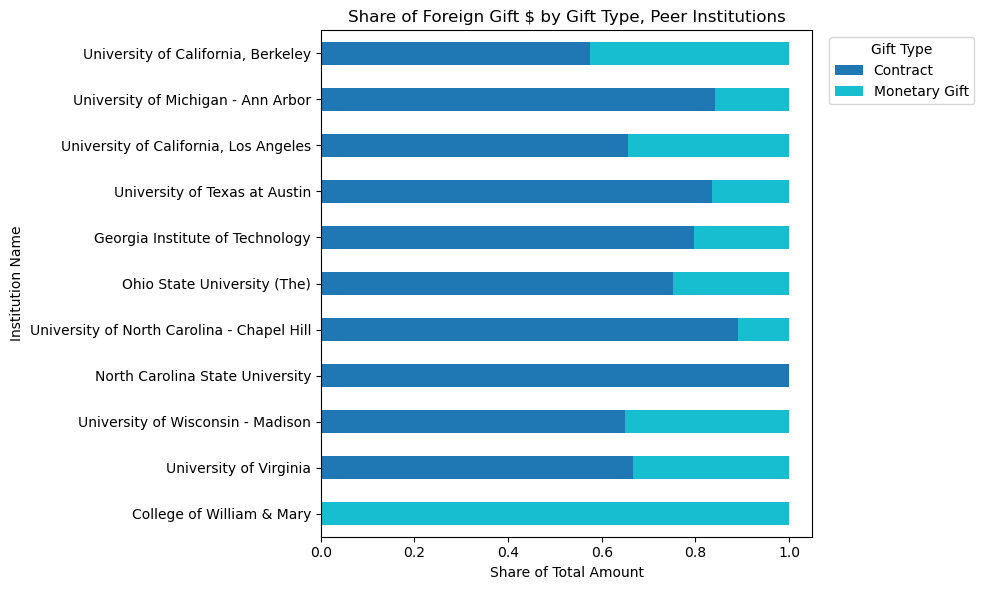

Gift Type,Contract,Monetary Gift
Institution Name,,
"University of California, Berkeley",0.58,0.42
University of Michigan - Ann Arbor,0.84,0.16
"University of California, Los Angeles",0.66,0.34
University of Texas at Austin,0.84,0.16
Georgia Institute of Technology,0.80,0.20
Ohio State University (The),0.75,0.25
University of North Carolina - Chapel Hill,0.89,0.11
North Carolina State University,1.00,0.00
University of Wisconsin - Madison,0.65,0.35


In [9]:
gift_type_by_peer = (
    peer_df.groupby(['Institution Name', 'Gift Type'])['Foreign Gift Amount']
    .sum()
    .unstack(fill_value=0)
)

gift_type_share = gift_type_by_peer.div(gift_type_by_peer.sum(axis=1), axis=0)
gift_type_share = gift_type_share.loc[peer_summary.index]  # order by total amount

gift_type_share.plot(kind='barh', stacked=True, figsize=(10, 6), colormap='tab10')
plt.title('Share of Foreign Gift $ by Gift Type, Peer Institutions')
plt.xlabel('Share of Total Amount')
plt.legend(title='Gift Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

gift_type_share

## Trend Over Time: UVA vs. Peer Average

How has UVA's foreign giving evolved by year, relative to the average peer institution?

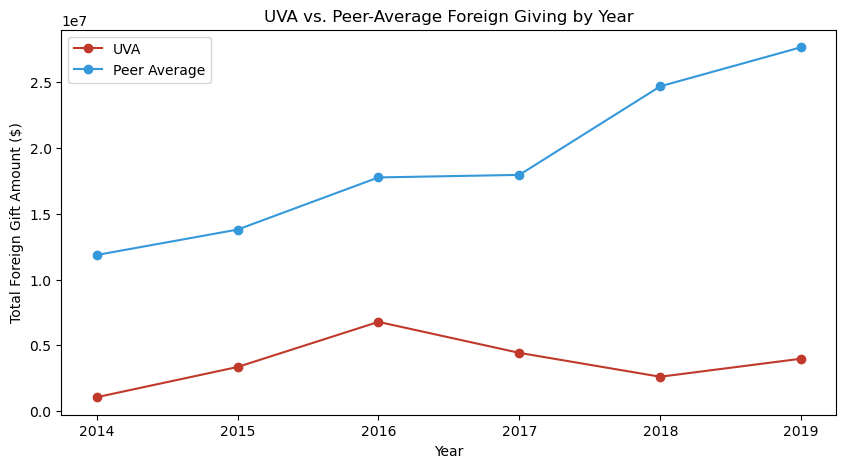

In [10]:
by_year = (
    peer_df.groupby(['Gift Year', 'Institution Name'])['Foreign Gift Amount']
    .sum()
    .unstack(fill_value=0)
)

other_peers = [p for p in PEERS if p != UVA]
peer_avg_by_year = by_year[other_peers].mean(axis=1)
uva_by_year = by_year[UVA]

plt.figure(figsize=(10, 5))
plt.plot(uva_by_year.index, uva_by_year.values, marker='o', label='UVA', color='#c0392b')
plt.plot(peer_avg_by_year.index, peer_avg_by_year.values, marker='o', label='Peer Average', color='#3498db')
plt.xlabel('Year')
plt.ylabel('Total Foreign Gift Amount ($)')
plt.title('UVA vs. Peer-Average Foreign Giving by Year')
plt.legend()
plt.show()

## Whitespace Analysis: Countries Where UVA Is Underrepresented

For each country, we compare how much peer institutions (excluding UVA) receive on average vs. how much UVA receives. Countries where peers receive substantially more than UVA (in total or per-institution average) represent potential **whitespace opportunities** — active donor markets where UVA is not yet capturing a proportional share.

In [11]:
other_peer_df = peer_df[peer_df['Institution Name'] != UVA]

peer_country_avg = (
    other_peer_df.groupby(['Institution Name', 'Country of Giftor'])['Foreign Gift Amount']
    .sum()
    .groupby('Country of Giftor')
    .mean()  # average total received by a peer institution, from this country
)

uva_country_total = uva_df.groupby('Country of Giftor')['Foreign Gift Amount'].sum()

whitespace = pd.DataFrame({
    'peer_avg_amount': peer_country_avg,
    'uva_amount': uva_country_total
}).fillna(0)

whitespace['gap'] = whitespace['peer_avg_amount'] - whitespace['uva_amount']
whitespace_sorted = whitespace.sort_values('gap', ascending=False)

print("Top 15 whitespace countries (peers earn much more than UVA, on average):")
whitespace_sorted.head(15)

Top 15 whitespace countries (peers earn much more than UVA, on average):


,peer_avg_amount,uva_amount,gap
Country of Giftor,,,
ENGLAND,"18,404,314.11","1,950,666.00","16,453,648.11"
PHILIPPINES,"16,325,267.00",0.00,"16,325,267.00"
JAPAN,"14,849,918.88","265,970.00","14,583,948.88"
CHINA,"11,680,691.50",0.00,"11,680,691.50"
SAUDI ARABIA,"9,296,070.00",0.00,"9,296,070.00"
GERMANY,"7,655,064.00",0.00,"7,655,064.00"
KOREA,"8,480,893.83","862,787.00","7,618,106.83"
HONG KONG,"7,554,176.86",0.00,"7,554,176.86"
DENMARK,"7,112,070.33",0.00,"7,112,070.33"


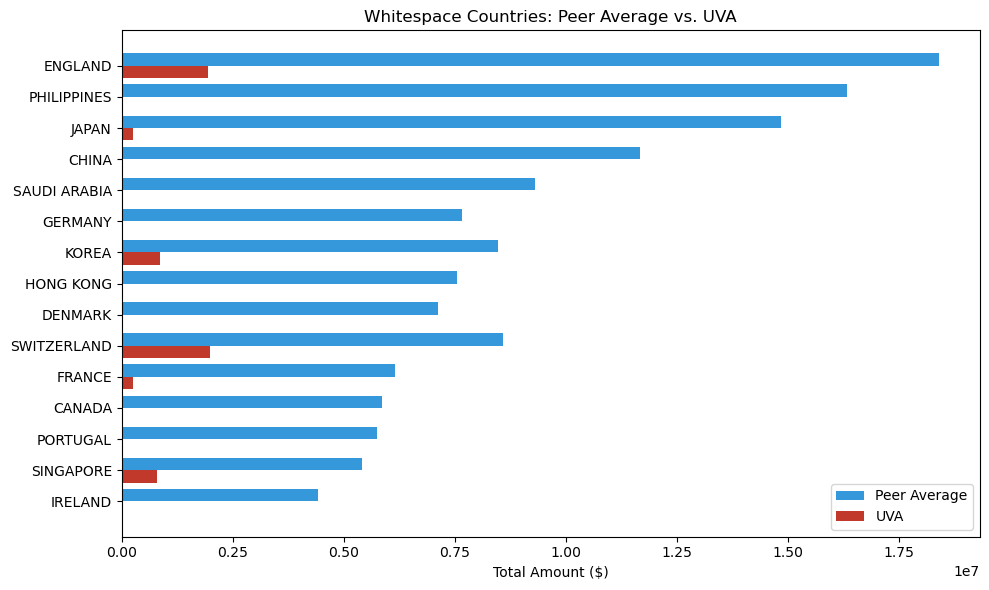

In [12]:
top_whitespace = whitespace_sorted.head(15)

plt.figure(figsize=(10, 6))
x = np.arange(len(top_whitespace))
width = 0.4
plt.barh(x - width/2, top_whitespace['peer_avg_amount'], height=width, label='Peer Average', color='#3498db')
plt.barh(x + width/2, top_whitespace['uva_amount'], height=width, label='UVA', color='#c0392b')
plt.yticks(x, top_whitespace.index)
plt.gca().invert_yaxis()
plt.xlabel('Total Amount ($)')
plt.title('Whitespace Countries: Peer Average vs. UVA')
plt.legend()
plt.tight_layout()
plt.show()

## UVA's Existing Donor Flows

An alluvial diagram of UVA's largest country → gift-type flows helps visualize the current base to build from.

In [13]:
flow_country_col = 'Country of Giftor'
flow_type_col = 'Gift Type'
flow_amount_col = 'Foreign Gift Amount'

uva_flows = (
    uva_df.groupby([flow_country_col, flow_type_col])[flow_amount_col]
    .sum()
    .reset_index()
)
uva_flows = uva_flows[uva_flows[flow_amount_col] > 0]

country_labels = uva_flows[flow_country_col].unique().tolist()
type_labels = uva_flows[flow_type_col].unique().tolist()
labels = country_labels + type_labels

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels, pad=15),
        link=dict(
            source=uva_flows[flow_country_col].map(labels.index),
            target=uva_flows[flow_type_col].map(lambda t: labels.index(t)),
            value=uva_flows[flow_amount_col]
        )
    )
)
fig.update_layout(title_text="UVA's Foreign Gift Flows: Country \u2192 Gift Type", font_size=10)
fig.show()

## Strategy: Growing UVA's Foreign Philanthropic Support

Based on the analysis above, we propose the following data-driven strategy:

1. Target the whitespace countries identified above: countries where peer institutions (e.g. UNC, Michigan, Berkeley, UCLA, Georgia Tech, Ohio State, UT Austin) receive substantially more, on average, than UVA. These represent active markets for US higher-education giving where UVA is under-penetrated relative to its peer set, not countries with no giving culture at all.
2. Diversify beyond current concentration: If UVA's giving is concentrated in a small number of countries, the Office of Development should invest in expanding relationships in other markets rather than over-relying on a few large donors, which is a fragile position (as seen market-wide with a few outlier country to institution mega-gifts).
3. Grow both gift types deliberately: Peers with a healthier mix of monetary gifts and contracts (ex: sponsored research agreements, corporate partnerships) tend to have larger and steadier total inflows. If UVA's mix is skewed toward one gift type relative to peers, that signals an opportunity, like building international research partnerships if Contracts are underrepresented, or expanding major-gift solicitation abroad if Monetary Gifts are underrepresented.
4. Learn from top peer flows: The country to institution mega-flows seen in the full market (e.g. Qatar, Bermuda-linked entities, England) suggest that a small number of large strategic partnerships (research institutes, named schools, or corporate-sponsored centers) can completely transform an institution's total foreign giving. UVA should pursue a few large and ongoing partnerships in its highest-potential whitespace countries rather than relying solely on a high volume of small gifts.
5. Monitor the trend line: The year-over-year comparison to the peer average should be tracked going forward as a KPI: is UVA's foreign giving growing faster or slower than the peer average? This analysis can be refreshed annually as new IRS Section 117 disclosure data becomes available.